© 2026 by Tamás Takács is licensed under CC BY-NC-SA 4.0. To view a copy of this license, visit https://creativecommons.org/licenses/by-nc-sa/4.0/

# Production Line Quality Control

> **[Hungarian AI Olympiad Online Qualification 2026/B](https://www.kaggle.com/competitions/magyar-mi-diakolimpia-online-valogato-2026-b)**
>
>
> This notebook was created **for educational purposes** after the competition concluded. We present data exploration, baseline solutions, then step by step we progress to semi-supervised learning methods, which achieved the best results.

## Table of Contents

1. [Loading and Overview of Data](#1)
2. [Exploratory Data Analysis (EDA)](#2)
3. [Baseline models, only labeled data](#3)
4. [Semi-supervised learning (SSL), using unlabeled data](#4)
5. [Per-cluster models](#5)
6. [Pseudo-labeling](#6)
7. [Comparison of results](#7)

## Task Summary

The competition modeled a **production line quality control** task, where sensor and process data had to be used to estimate whether a product is **defective** (binary classification).

| Property | Value |
|-------------|-------|
| **Labeled training samples** | 150 |
| **Unlabeled training samples** | 12,850 |
| **Test samples** | 2,000 |
| **Number of features** | 33 numerical + 1 categorical |
| **Target variable** | `Defective` (0 or 1) |
| **Metric** | AUC-ROC |

The main challenge: **very little labeled data** is available, but many unlabeled samples are also accessible. This is a classic **semi-supervised learning** (SSL) situation.

<a name="1"></a>
# 1. Loading and Overview of Data

### Required imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import roc_auc_score, roc_curve, silhouette_score
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
np.random.seed(42)

%matplotlib inline

### Reading the data

The competition provided four files:
- `train_labeled.csv`: 150 labeled samples (sensor features + `Defective` target variable)
- `train_unlabeled.csv`: 12,850 unlabeled samples (same features, but without `Defective`)
- `test.csv`: 2,000 test samples (predictions had to be submitted)
- `sample_submission.csv`: template of the submission format

Since the competition has ended, `solution.csv` is also available for evaluation.

In [2]:
import os

!gdown 146OjOF2-6dYXYnWUtkpLxZATR1w3YGpi -O train_labeled.csv
!gdown 1iXAkJErkAU9akpgEfZI7Lmtc0jq0_cDP -O train_unlabeled.csv
!gdown 1hQE4HkRRccOKfQbdZrmIQuxqe2_mJ0NF -O test.csv
!gdown 1kD-WRIkl44FAZQvHZcYGfmVehcLANLH2 -O solution.csv

KAGGLE_DIR = '/kaggle/input/magyar-mi-diakolimpia-online-valogato-2026-b/'
INPUT_DIR = KAGGLE_DIR if os.path.exists(KAGGLE_DIR) else './'

train_labeled = pd.read_csv(INPUT_DIR + 'train_labeled.csv')
train_unlabeled = pd.read_csv(INPUT_DIR + 'train_unlabeled.csv')
test_df = pd.read_csv(INPUT_DIR + 'test.csv')
solution = pd.read_csv(INPUT_DIR + 'solution.csv')

test_with_labels = test_df.merge(solution[['ID', 'Selejt']], on='ID')

print(f"\nLabeled training data:   {train_labeled.shape[0]:>6,} samples, {train_labeled.shape[1]} columns")
print(f"Unlabeled training data: {train_unlabeled.shape[0]:>6,} samples, {train_unlabeled.shape[1]} columns")
print(f"Test data:               {test_df.shape[0]:>6,} samples, {test_df.shape[1]} columns")
print(f"\nDefective ratio (labeled): {train_labeled['Selejt'].mean():.1%}")
print(f"Defective ratio (test):     {test_with_labels['Selejt'].mean():.1%}")

Downloading...
From: https://drive.google.com/uc?id=146OjOF2-6dYXYnWUtkpLxZATR1w3YGpi
To: c:\Users\raian\source\repos\AI\IOAI_prep\hungary\2026\ml_gold_standard\train_labeled.csv

  0%|          | 0.00/95.3k [00:00<?, ?B/s]
100%|██████████| 95.3k/95.3k [00:00<00:00, 23.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1iXAkJErkAU9akpgEfZI7Lmtc0jq0_cDP
To: c:\Users\raian\source\repos\AI\IOAI_prep\hungary\2026\ml_gold_standard\train_unlabeled.csv

  0%|          | 0.00/8.10M [00:00<?, ?B/s]
  6%|▋         | 524k/8.10M [00:00<00:02, 3.38MB/s]
 13%|█▎        | 1.05M/8.10M [00:00<00:02, 3.34MB/s]
 19%|█▉        | 1.57M/8.10M [00:00<00:01, 3.87MB/s]
 26%|██▌       | 2.10M/8.10M [00:00<00:01, 3.79MB/s]
 32%|███▏      | 2.62M/8.10M [00:00<00:01, 3.83MB/s]
 45%|████▌     | 3.67M/8.10M [00:00<00:00, 4.46MB/s]
 58%|█████▊    | 4.72M/8.10M [00:01<00:00, 5.30MB/s]
 71%|███████   | 5.77M/8.10M [00:01<00:00, 5.72MB/s]
 84%|████████▍ | 6.82M/8.10M [00:01<00:00, 5.56MB/s]
 97%|█████████▋| 7.86


Labeled training data:      150 samples, 35 columns
Unlabeled training data: 12,850 samples, 34 columns
Test data:                2,000 samples, 34 columns

Defective ratio (labeled): 45.3%
Defective ratio (test):     44.1%


In [3]:
train_labeled.head()

,ID,Hőmérséklet,Nyomás,Rezgés,Feszültség,Nyomaték,Szerszám_Kopás,Karbantartás_Óta_Eltelt_Idő,Páratartalom,Fordulat,...,Szenzor_11,Szenzor_12,Szenzor_13,Szenzor_14,Szenzor_15,Szenzor_16,Szenzor_17,Szenzor_18,Gyártósor,Selejt
0,ITEM_00000,75.907041,3.831936,51.472834,217.098007,38.316036,228.361172,155.478734,64.597543,1389.297668,...,-0.742682,-0.902517,1.159349,-0.379631,1.747762,-1.598339,-2.352235,0.497678,Vonal_E,1
1,ITEM_00001,81.242746,5.357322,25.553280,230.298673,48.384111,21.935034,69.234019,35.211917,1672.997915,...,-0.750481,1.624672,0.744649,-1.176670,0.750373,-0.302829,0.939427,-0.567894,Vonal_A,0
2,ITEM_00002,74.004248,3.971429,19.762415,205.499735,32.403428,167.193096,124.985486,72.651122,1183.049348,...,-1.450498,1.675769,1.374522,-0.527704,-0.278072,0.208900,0.857715,0.147685,Vonal_B,1
3,ITEM_00003,73.061348,2.542578,44.395338,233.853194,31.420680,113.907234,103.992968,61.111509,1490.947877,...,-1.158815,0.822962,1.127353,-1.257186,1.012118,0.170600,0.387113,1.377332,Vonal_C,0
4,ITEM_00004,82.929130,4.704838,18.821581,237.629698,67.618695,66.443431,69.115467,40.095704,1790.750438,...,-0.853669,-0.341559,2.165415,-0.228110,0.275952,0.705621,-0.695425,2.051832,Vonal_B,1


### Column descriptions

The dataset contains the following features:

**Physical sensor data:**
- `Temperature`: production temperature (°C)
- `Pressure`: production pressure (bar)
- `Vibration`: machine vibration level (mm/s)
- `Voltage`: electrical voltage (V)
- `Torque`: mechanical torque (Nm)
- `Humidity`: ambient humidity (%)
- `RPM`: rotational speed (RPM)

**Maintenance data:**
- `Tool_Wear`: measure of tool wear
- `Time_Since_Last_Maintenance`: time elapsed since last maintenance (hours)

**Derived features:**
- `Temp_Pressure_Product`, `Vibration_Torque_Ratio`, `Wear_Maintenance_Product`, `Voltage_RPM_Ratio`, `Humidity_Temp_Product`

**Sensor measurements:**
- `Sensor_01` - `Sensor_18`: other sensor values (these are actually **noise features**)

**Other:**
- `Production_Line`: categorical (Line_A - Line_E)
- `Defective`: binary target variable (only in labeled data)

In [4]:
train_labeled.describe().round(2)

,Hőmérséklet,Nyomás,Rezgés,Feszültség,Nyomaték,Szerszám_Kopás,Karbantartás_Óta_Eltelt_Idő,Páratartalom,Fordulat,Hő_Nyomás_Szorzat,...,Szenzor_10,Szenzor_11,Szenzor_12,Szenzor_13,Szenzor_14,Szenzor_15,Szenzor_16,Szenzor_17,Szenzor_18,Selejt
count,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00,...,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00
mean,72.55,3.95,30.86,225.06,42.46,131.51,104.94,56.90,1466.10,3.00,...,0.00,-0.10,0.05,-0.08,-0.07,0.27,-0.01,-0.14,-0.08,0.45
std,11.02,1.20,11.84,12.66,11.46,56.57,44.94,11.15,277.46,1.38,...,1.05,1.03,1.02,1.02,0.95,0.93,0.95,1.04,1.01,0.50
min,44.53,1.58,7.73,198.20,15.83,21.94,12.99,35.21,777.03,0.57,...,-2.82,-2.98,-2.24,-3.49,-2.45,-2.20,-2.72,-2.56,-2.43,0.00
25%,64.28,2.96,21.24,215.54,34.13,88.72,69.11,48.68,1269.73,2.10,...,-0.71,-0.75,-0.70,-0.71,-0.74,-0.35,-0.65,-0.97,-0.80,0.00
50%,72.06,3.84,28.06,225.27,41.32,116.68,100.40,55.79,1474.39,2.64,...,-0.02,-0.12,0.03,-0.05,0.01,0.30,-0.05,-0.03,-0.06,0.00
75%,79.48,4.78,39.39,235.98,49.66,167.17,130.18,63.47,1660.92,3.82,...,0.66,0.54,0.81,0.61,0.58,0.85,0.57,0.51,0.59,1.00
max,101.53,6.45,61.16,252.13,71.79,292.72,223.01,85.99,2184.07,6.87,...,2.66,2.23,2.59,2.17,2.88,2.27,2.50,3.07,2.62,1.00


<a name="2"></a>
# 2. Exploratory Data Analysis (EDA)

The goal of exploratory analysis is to understand the structure, distributions, and potential hidden patterns in the data. It is particularly important to **compare the labeled and unlabeled data**; if their distributions are similar, that is a good sign for SSL methods.

## 2.1 Distribution of the target variable

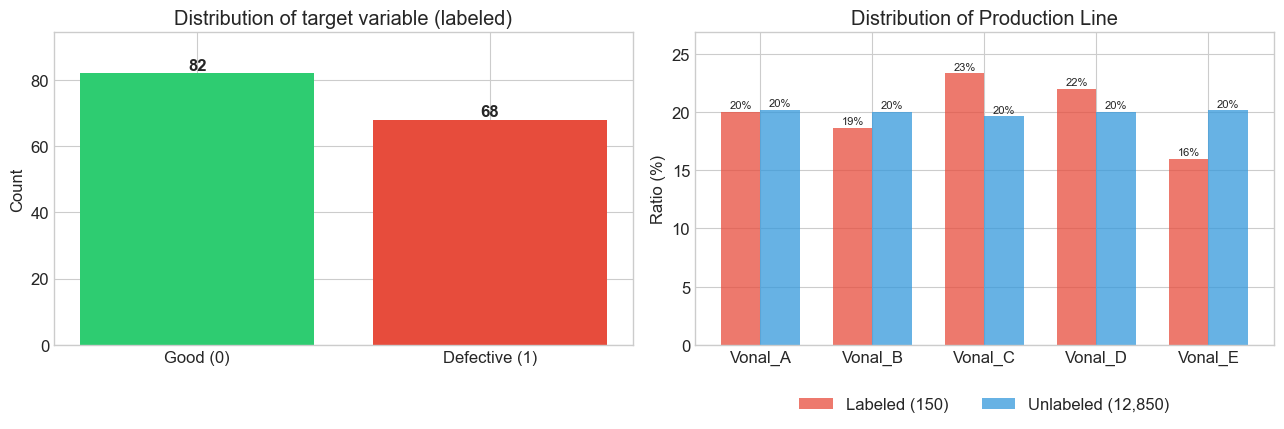

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

counts = train_labeled['Selejt'].value_counts().sort_index()
axes[0].bar(['Good (0)', 'Defective (1)'], counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribution of target variable (labeled)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')
axes[0].set_ylim(0, max(counts.values) * 1.15)

lines = sorted(train_labeled['Gyártósor'].unique())
x = np.arange(len(lines))
width = 0.35
all_pcts = []
for j, (label, df, color) in enumerate([
    ('Labeled (150)', train_labeled, '#e74c3c'),
    ('Unlabeled (12,850)', train_unlabeled, '#3498db'),
]):
    vc = df['Gyártósor'].value_counts()
    pcts = [vc.get(v, 0) / len(df) * 100 for v in lines]
    all_pcts.extend(pcts)
    bars = axes[1].bar(x + j * width, pcts, width, label=label, color=color, alpha=0.75)
    for bar, pct in zip(bars, pcts):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{pct:.0f}%', ha='center', fontsize=8)

axes[1].set_xticks(x + width / 2)
axes[1].set_xticklabels(lines)
axes[1].set_title('Distribution of Production Line')
axes[1].set_ylabel('Ratio (%)')
axes[1].set_ylim(0, max(all_pcts) * 1.15)
axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2)

plt.tight_layout()
plt.show()

## 2.2 Distribution of features

Let's examine the distribution of the main physical sensor data. We compare **labeled** and **unlabeled** data; if they are similar, it means we can also learn from the unlabeled data (e.g., via clustering).

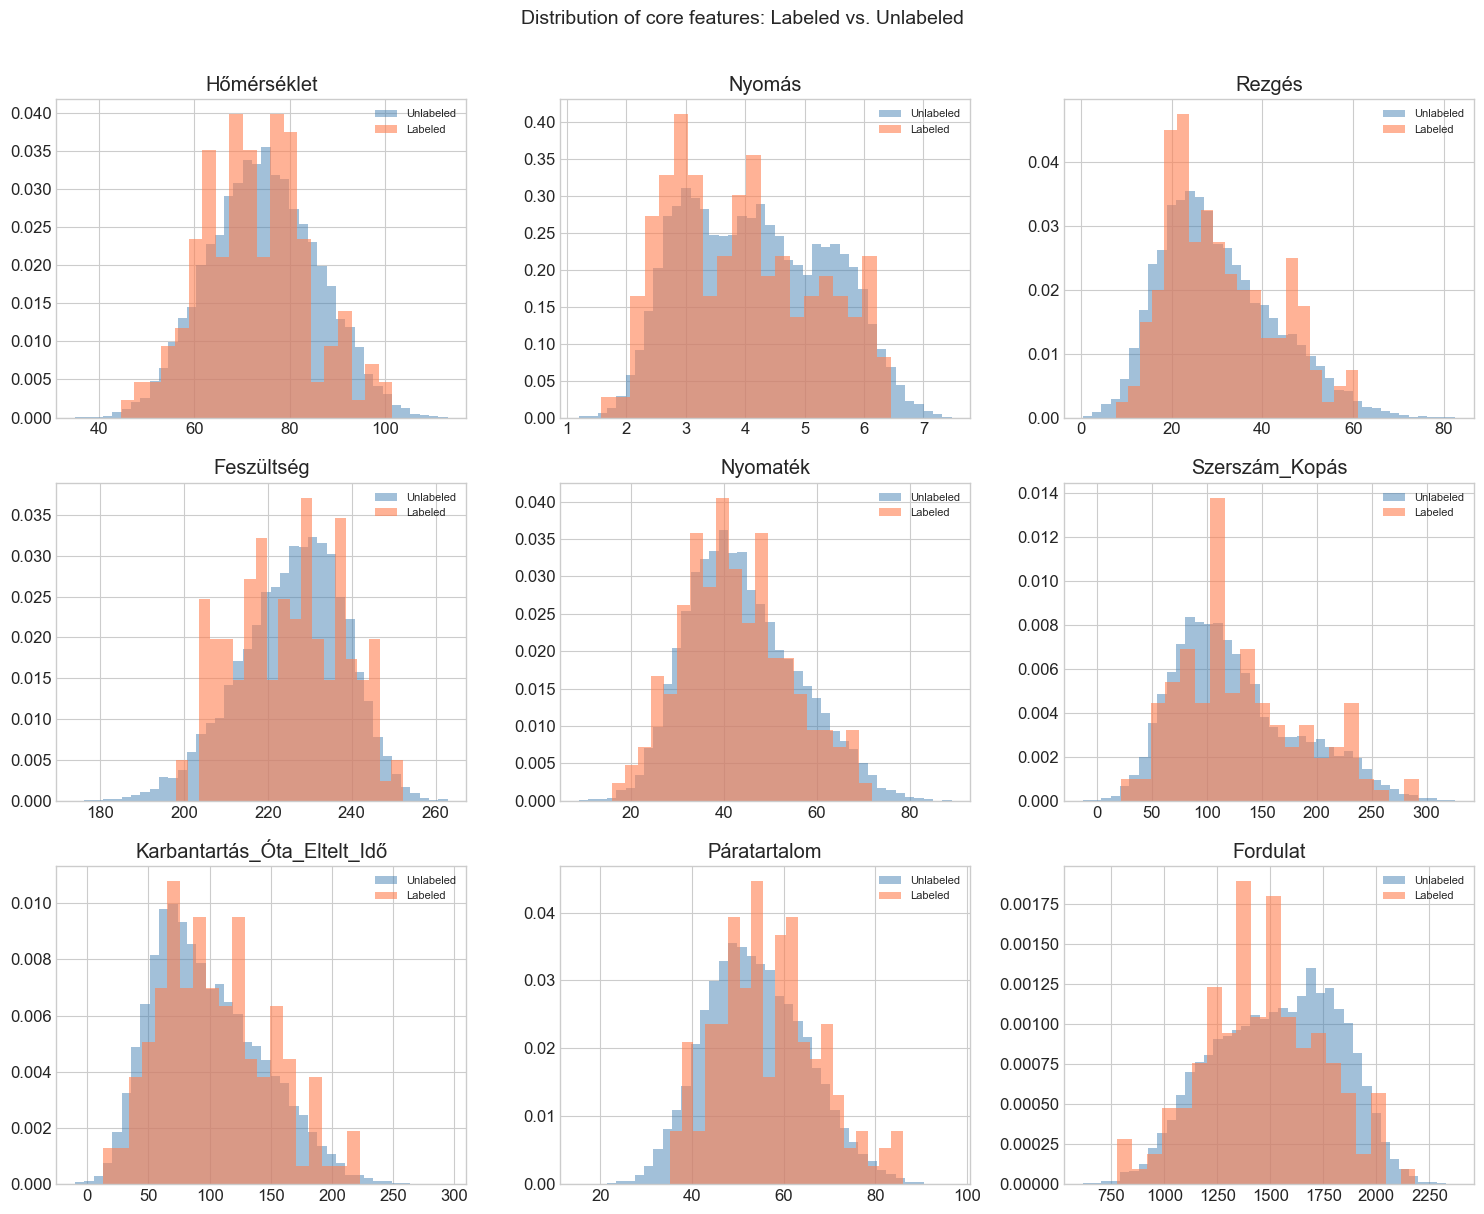

In [6]:
core_features = ['Hőmérséklet', 'Nyomás', 'Rezgés', 'Feszültség', 'Nyomaték',
                 'Szerszám_Kopás', 'Karbantartás_Óta_Eltelt_Idő', 'Páratartalom', 'Fordulat']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for i, feat in enumerate(core_features):
    ax = axes[i // 3, i % 3]
    ax.hist(train_unlabeled[feat], bins=40, alpha=0.5, density=True, label='Unlabeled', color='steelblue')
    ax.hist(train_labeled[feat], bins=20, alpha=0.6, density=True, label='Labeled', color='coral')
    ax.set_title(feat)
    ax.legend(fontsize=8)

plt.suptitle('Distribution of core features: Labeled vs. Unlabeled', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Observation

The distribution of the `Pressure` feature is clearly **multimodal**, indicating the existence of **hidden subgroups** (clusters) in the data. The distribution of several other features (e.g., `Tool_Wear`, `RPM`, `Vibration`) is also wider than usual, which might also suggest a mixed population, although this is less clear on its own.



## 2.3 Relationship between features and target variable

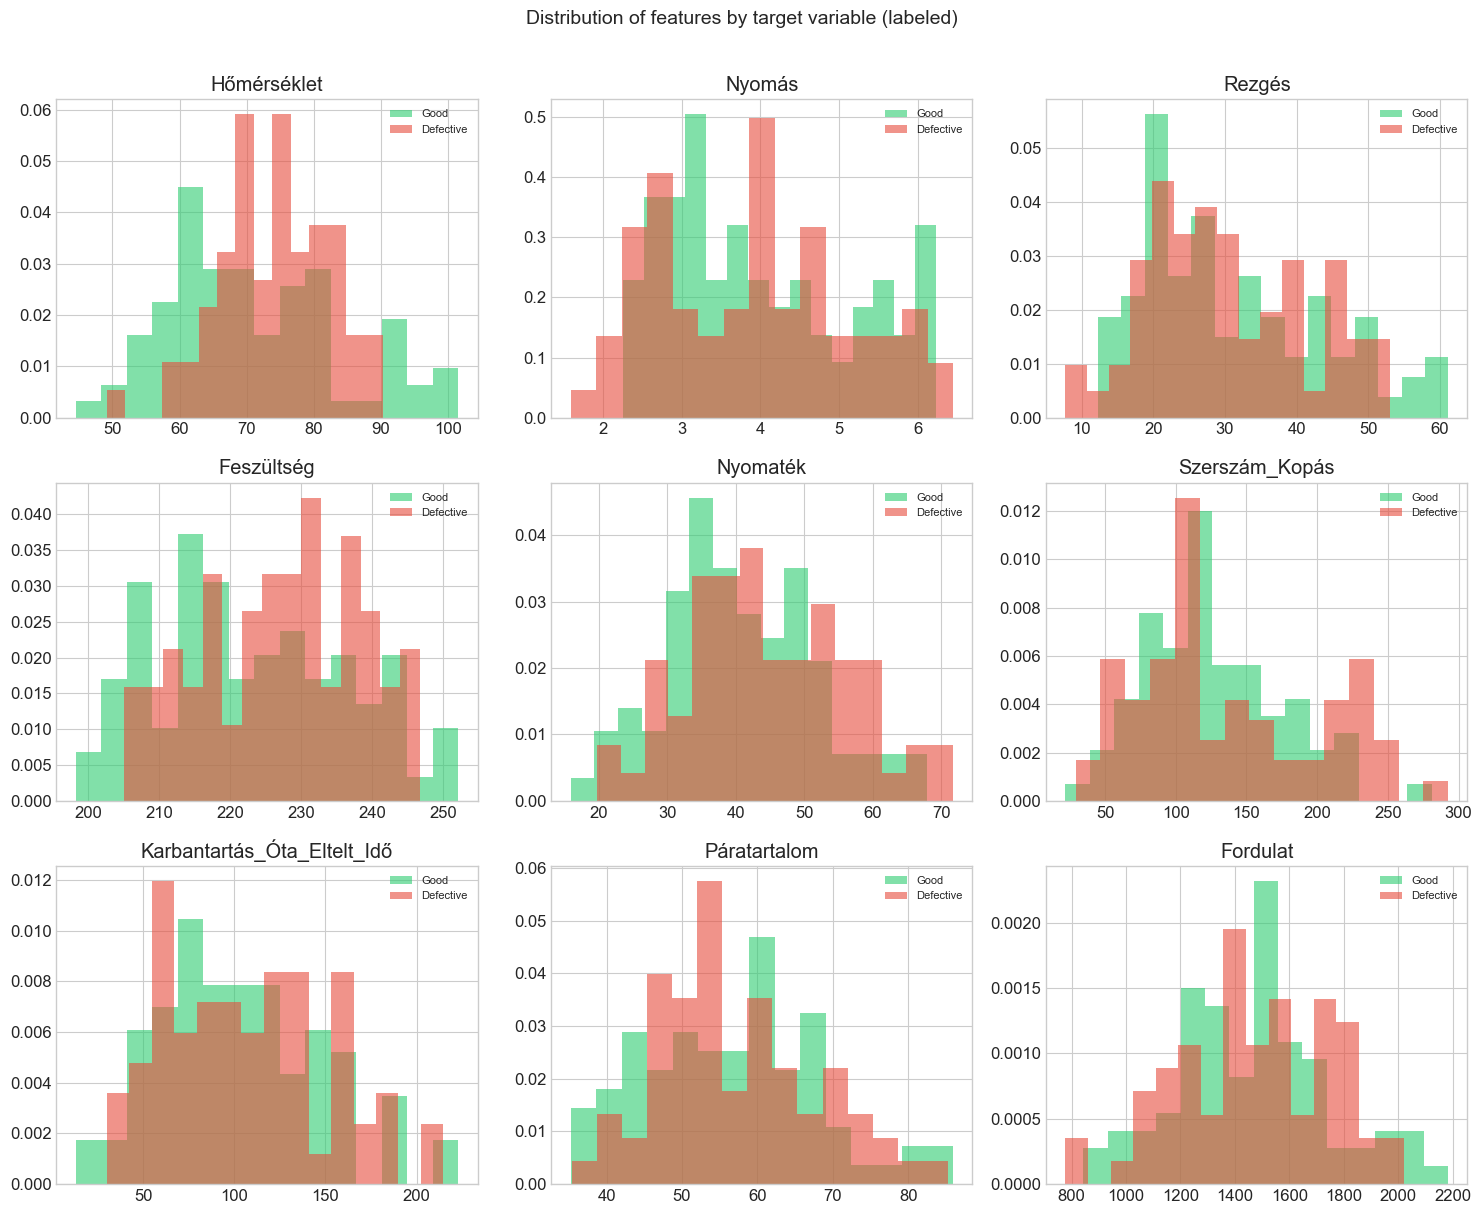

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for i, feat in enumerate(core_features):
    ax = axes[i // 3, i % 3]
    for val, color, label in [(0, '#2ecc71', 'Good'), (1, '#e74c3c', 'Defective')]:
        subset = train_labeled[train_labeled['Selejt'] == val]
        ax.hist(subset[feat], bins=15, alpha=0.6, density=True, label=label, color=color)
    ax.set_title(feat)
    ax.legend(fontsize=8)

plt.suptitle('Distribution of features by target variable (labeled)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Observation

Globally, the distributions of defective and good products **largely overlap**; no single feature clearly separates them. This is because defectiveness **depends on different features in different subgroups** (hidden states). A global model cannot learn this effectively, especially from 150 samples.



## 2.4 Correlation matrix

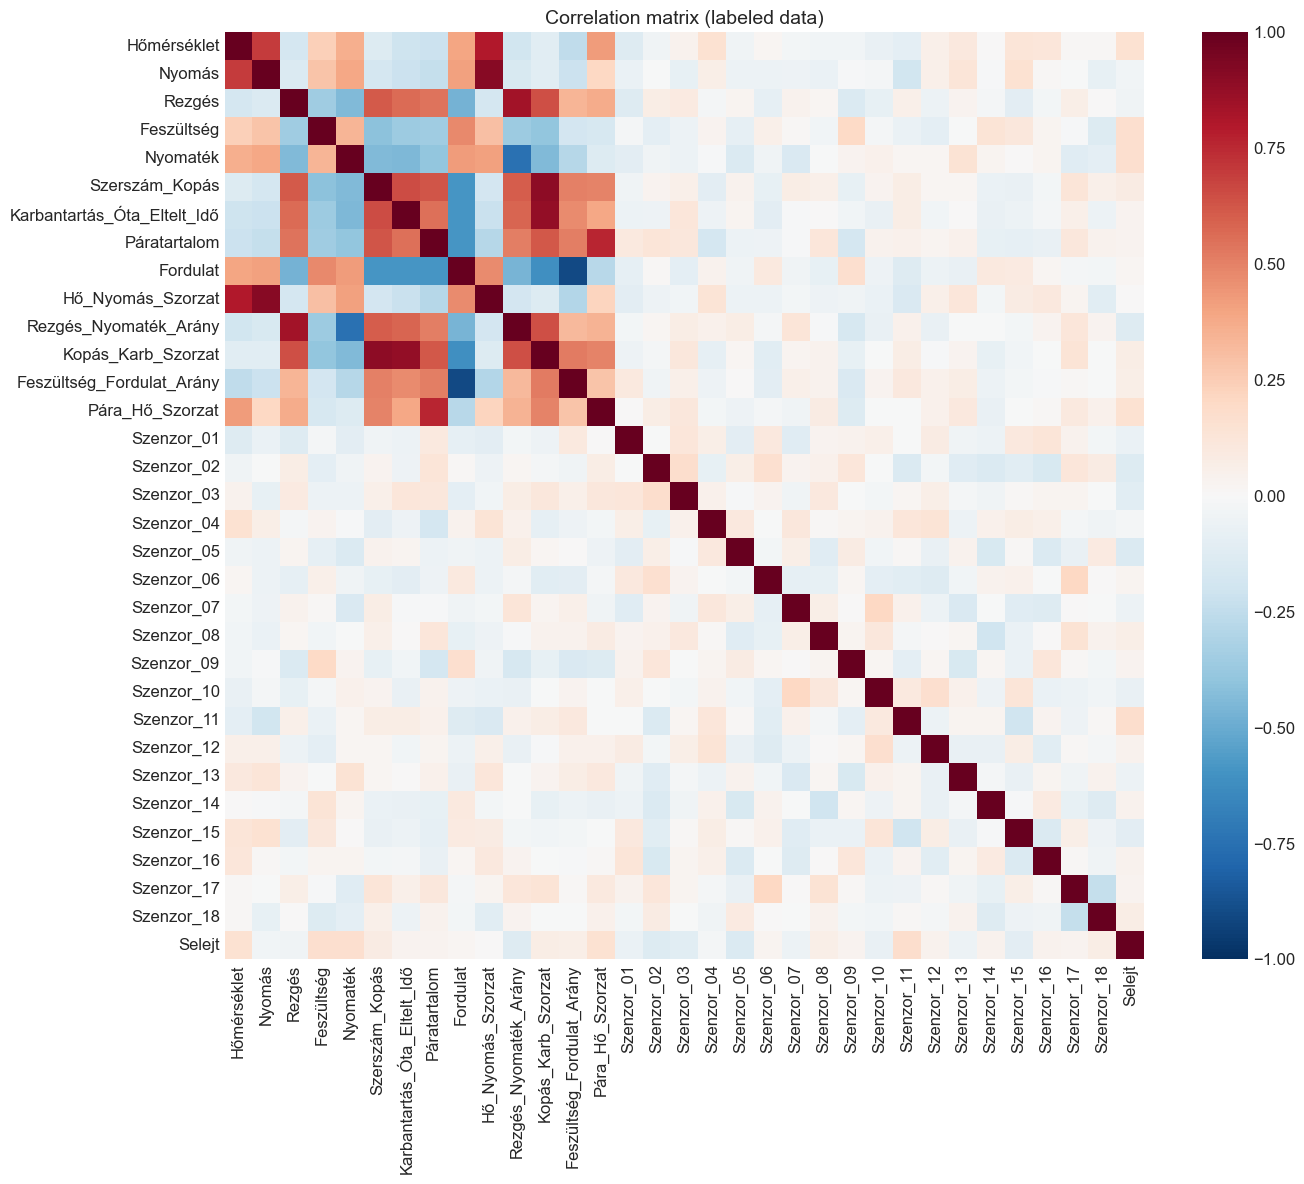


Correlation with the Defective variable (top 10 strongest):
  Szenzor_11                           +0.178
  Nyomaték                             +0.170
  Feszültség                           +0.167
  Pára_Hő_Szorzat                      +0.153
  Hőmérséklet                          +0.149
  Szenzor_05                           −0.142
  Szenzor_02                           −0.139
  Rezgés_Nyomaték_Arány                −0.128
  Szenzor_03                           −0.115
  Szenzor_15                           −0.106


In [ ]:
numeric_cols = train_labeled.select_dtypes(include=[np.number]).columns.drop('ID', errors='ignore')
corr = train_labeled[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr,  cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax,
            annot=False)
ax.set_title('Correlation matrix (labeled data)', fontsize=14)
plt.tight_layout()
plt.show()

# Correlation with the target variable
target_corr = corr['Selejt'].drop('Selejt')
top10 = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index).head(10)
print("\nCorrelation with the Defective variable (top 10 strongest):")
for feat, val in top10.items():
    direction = "+" if val > 0 else "−"
    print(f"  {feat:35s}  {direction}{abs(val):.3f}")

### Observation

The correlations with the target variable are quite **weak**. This is not surprising: as we will see, defectiveness depends on different features in different subgroups of the data. Therefore, global linear correlation cannot show a strong relationship.

The **Sensor_01 - Sensor_18** features hardly correlate with anything at all.

## 2.5 PCA visualization

Principal Component Analysis (PCA) helps to visualize multidimensional data in 2D. If there is a cluster structure in the data, it will also appear here.

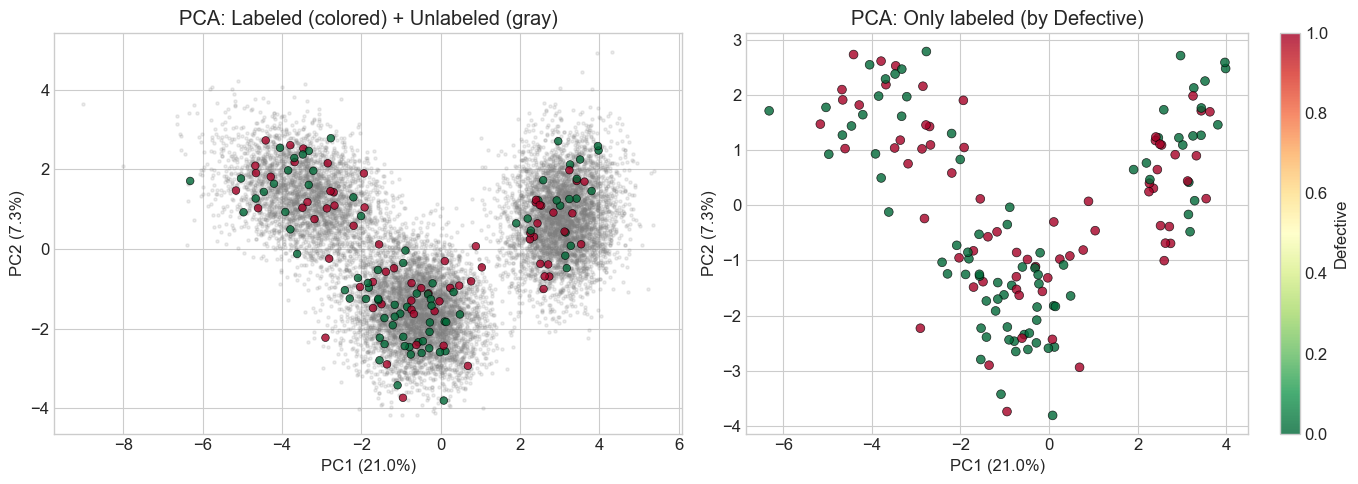


Explained variance (PC1 + PC2): 28.3%


In [13]:
# Preparation: LabelEncoder and StandardScaler
le = LabelEncoder()
all_lines = pd.concat([train_labeled['Gyártósor'], train_unlabeled['Gyártósor'], test_df['Gyártósor']])
le.fit(all_lines)

def prep(df):
    """Feature preparation: encode Production_Line, remove ID and Defective."""
    df = df.copy()
    y = df.pop('Selejt') if 'Selejt' in df.columns else None
    df.drop(columns=['ID'], errors='ignore', inplace=True)
    df['Gyártósor'] = le.transform(df['Gyártósor'])
    return df, y

X_labeled, y_labeled = prep(train_labeled)
X_test, y_test = prep(test_with_labels) # Use test_with_labels to get true y_test
X_unlabeled, _ = prep(train_unlabeled)

scaler = StandardScaler()
X_labeled_s = scaler.fit_transform(X_labeled)
X_test_s = scaler.transform(X_test)
X_unlabeled_s = scaler.transform(X_unlabeled)

# PCA on all training data (labeled + unlabeled)
X_all = np.vstack([X_labeled_s, X_unlabeled_s])
pca = PCA(n_components=2)
X_all_2d = pca.fit_transform(X_all)
X_labeled_2d = X_all_2d[:len(X_labeled)]
X_unlabeled_2d = X_all_2d[len(X_labeled):]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Unlabeled data (cluster structure)
axes[0].scatter(X_unlabeled_2d[:, 0], X_unlabeled_2d[:, 1], alpha=0.15, s=5, c='gray')
axes[0].scatter(X_labeled_2d[:, 0], X_labeled_2d[:, 1], alpha=0.8, s=30,
               c=y_labeled, cmap='RdYlGn_r', edgecolors='black', linewidths=0.5)
axes[0].set_title('PCA: Labeled (colored) + Unlabeled (gray)')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

# Only labeled, colored by target variable
scatter = axes[1].scatter(X_labeled_2d[:, 0], X_labeled_2d[:, 1], alpha=0.8, s=40,
                          c=y_labeled, cmap='RdYlGn_r', edgecolors='black', linewidths=0.5)
axes[1].set_title('PCA: Only labeled (by Defective)')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.colorbar(scatter, ax=axes[1], label='Defective')

plt.tight_layout()
plt.show()

print(f"\nExplained variance (PC1 + PC2): {pca.explained_variance_ratio_[:2].sum():.1%}")


### Observation

The PCA plot clearly shows that there are **2-3 separable groups** in the data. This cluster structure appears in both the labeled and unlabeled data. Defective and good products **do not separate clearly** in the global PCA space, but notice that **their distribution differs per cluster**!



<a name="3"></a>
# 3. Baseline models (only labeled data)

First, we train models **exclusively on the 150 labeled samples**, without using the unlabeled data. This provides the baseline to which we will compare the SSL methods.

### Helper functions

In [14]:
# Collecting results
results = {}

def evaluate(name, y_true, y_prob):
    """Evaluate model and save result."""
    auc = roc_auc_score(y_true, y_prob)
    results[name] = auc
    print(f"{name}: AUC-ROC = {auc:.4f}")

## 3.1 Logistic Regression

The **simplest baseline**: a linear model that returns probabilities. The starter notebook also contained this.

In [15]:
# Logistic regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_labeled_s, y_labeled)
evaluate("Logistic Regression", y_test, lr.predict_proba(X_test_s)[:, 1])

Logistic Regression: AUC-ROC = 0.6230


## 3.2 Random Forest

Ensemble model that predicts by voting of decision trees. Does not require scaling (trained on original features).

In [16]:
# Random Forest (on non-scaled data)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_labeled, y_labeled)
evaluate("Random Forest", y_test, rf.predict_proba(X_test)[:, 1])

Random Forest: AUC-ROC = 0.7052


## 3.3 Gradient Boosting (GBM)

**Gradient Boosting** is typically the strongest model for tabular data. It builds decision trees sequentially, each one correcting the error of the previous one.

In [17]:
# GBM (default)
gbm = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
gbm.fit(X_labeled_s, y_labeled)
evaluate("GBM (default)", y_test, gbm.predict_proba(X_test_s)[:, 1])

# GBM (tuned)
gbm_tuned = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.08, random_state=42)
gbm_tuned.fit(X_labeled_s, y_labeled)
evaluate("GBM (tuned)", y_test, gbm_tuned.predict_proba(X_test_s)[:, 1])

GBM (default): AUC-ROC = 0.7286
GBM (tuned): AUC-ROC = 0.7431


The best baseline (only labeled data) was the **tuned GBM**, but its AUC value can certainly be improved. With 150 samples, 33 features (18 of which are noise), a global model has a hard time.

> **How can we use the 12,850 unlabeled samples to improve?**


<a name="4"></a>
# 4. Semi-supervised learning (SSL)

Semi-supervised learning (SSL) means that we **also learn from the unlabeled data**, not directly the labels, but the **structure** of the data.

### Hidden structure of the data

The key insight: there are **3 hidden machine states** (clusters) in the data, in which defectiveness **depends on different features**:

| State | Increases defect | Decreases defect | Special |
|---------|-----------------|--------------------|-----------|
| **0** | Temperature, Vibration | Pressure | Temperature positive effect |
| **1** | Torque, Maintenance | Temperature | Temperature **negative** effect! |
| **2** | Tool_Wear, Voltage | Vibration | Vibration **negative** effect! |

This means that if Temperature increases:
- In **state 0** this **increases** the chance of defect
- In **state 1** this **decreases** the chance of defect

A global model cannot resolve this contradiction! However, if we **split the data into clusters**, the relationship becomes simple in each cluster and can be learned from few samples.

## 4.1 Clustering with KMeans

We run the `KMeans` algorithm on **all** training data (labeled + unlabeled), with K=3 clusters.

In [18]:
# KMeans clustering on the entire training data (labeled + unlabeled)
km = KMeans(n_clusters=3, random_state=42, n_init=20)
km.fit(X_all)

cluster_labeled = km.labels_[:len(X_labeled)]
cluster_unlabeled = km.labels_[len(X_labeled):]
cluster_test = km.predict(X_test_s)

print("Cluster distribution (all training data):")
unique, counts = np.unique(km.labels_, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c:>5,} samples ({c/len(km.labels_):.1%})")

print(f"\nCluster distribution (labeled, ~50 samples/cluster):")
for cl in range(3):
    n = (cluster_labeled == cl).sum()
    defect_rate = y_labeled.values[cluster_labeled == cl].mean()
    print(f"  Cluster {cl}: {n:>3} samples, defect ratio = {defect_rate:.1%}")

Cluster distribution (all training data):
  Cluster 0: 3,242 samples (24.9%)
  Cluster 1: 5,167 samples (39.7%)
  Cluster 2: 4,591 samples (35.3%)

Cluster distribution (labeled, ~50 samples/cluster):
  Cluster 0:  40 samples, defect ratio = 52.5%
  Cluster 1:  70 samples, defect ratio = 38.6%
  Cluster 2:  40 samples, defect ratio = 50.0%


### Visualization of clusters with PCA

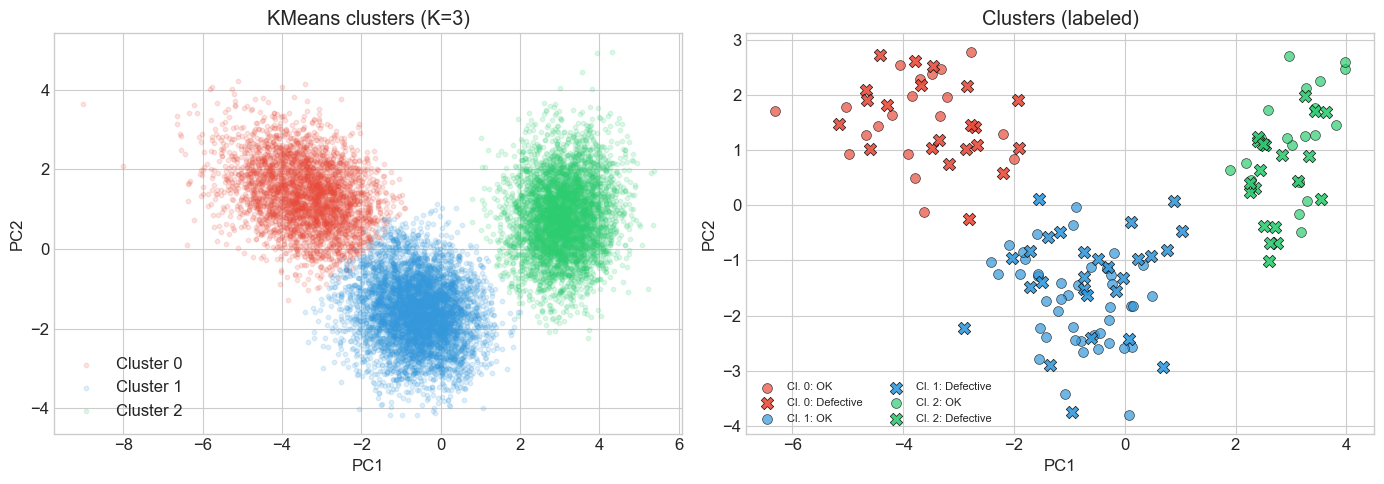

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c', '#3498db', '#2ecc71']

# Clusters on all data
for cl in range(3):
    mask = km.labels_ == cl
    axes[0].scatter(X_all_2d[mask, 0], X_all_2d[mask, 1], alpha=0.15, s=10, c=colors[cl], label=f'Cluster {cl}')
axes[0].set_title('KMeans clusters (K=3)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

# Clusters on labeled data, marking defect
for cl in range(3):
    mask = cluster_labeled == cl
    x = X_labeled_2d[mask]
    y = y_labeled.values[mask]
    axes[1].scatter(x[y == 0, 0], x[y == 0, 1], marker='o', s=50, c=colors[cl], alpha=0.7,
                   edgecolors='black', linewidths=0.5, label=f'Cl. {cl}: OK')
    axes[1].scatter(x[y == 1, 0], x[y == 1, 1], marker='X', s=80, c=colors[cl], alpha=0.9,
                   edgecolors='black', linewidths=0.5, label=f'Cl. {cl}: Defective')
axes[1].set_title('Clusters (labeled)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

## 4.2 How to choose K?

Choosing K is an important question. Two common methods:

- **Elbow method**: Observe the decrease in within-cluster sum of squares (inertia) as a function of K. Where the curve "breaks", that is the optimal K.
- **Silhouette score**: Measures how well each point fits into its own cluster compared to neighboring clusters (higher is better). The Silhouette is often highest at K=2 (because that is the most trivial split), but the **second peak** or **elbow** appearing at K=3 indicates that the natural structure of the data contains 3 groups.

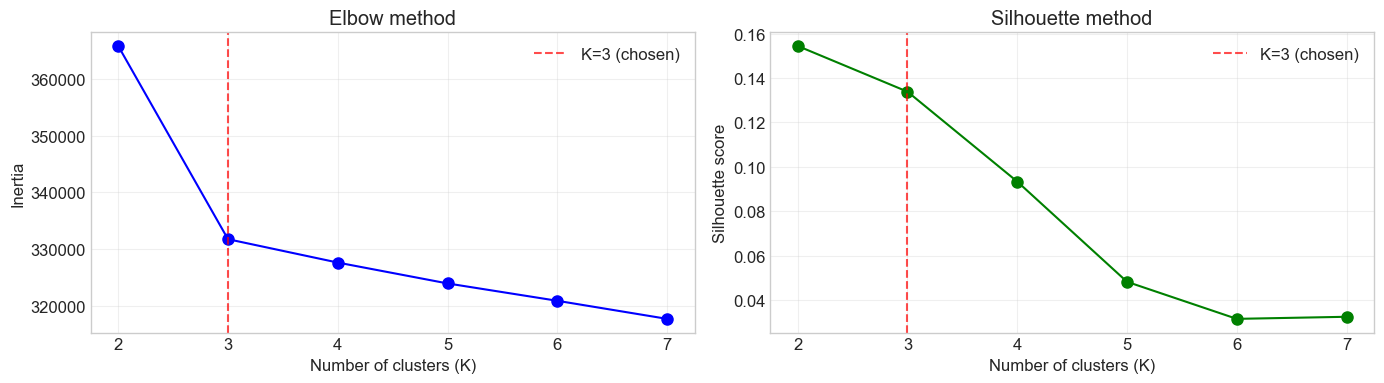


 Best Silhouette score: K=2 (0.154)


In [21]:
inertias = []
silhouettes = []
K_range = range(2, 8)
for k in K_range:
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km_temp.fit_predict(X_all)
    inertias.append(km_temp.inertia_)
    silhouettes.append(silhouette_score(X_all, labels, sample_size=5000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(K_range, inertias, 'bo-', markersize=8)
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='K=3 (chosen)')
axes[0].set_xlabel('Number of clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow method')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouettes, 'go-', markersize=8)
axes[1].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='K=3 (chosen)')
axes[1].set_xlabel('Number of clusters (K)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette method')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_k = list(K_range)[np.argmax(silhouettes)]
print(f"\n Best Silhouette score: K={best_k} ({max(silhouettes):.3f})")

## 4.3 Cluster as a feature

The first, simpler SSL approach: add the cluster assignment as a **new feature** to the model. This is not per-cluster training, but a single global model that also uses the cluster information.

In [22]:
# Adding cluster-ID as a feature
X_labeled_cl = np.column_stack([X_labeled_s, cluster_labeled])
X_test_cl = np.column_stack([X_test_s, cluster_test])

gbm_cl = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
gbm_cl.fit(X_labeled_cl, y_labeled)
evaluate("SSL: Cluster as feature (K=3)", y_test, gbm_cl.predict_proba(X_test_cl)[:, 1])

SSL: Cluster as feature (K=3): AUC-ROC = 0.7340


The cluster feature brings **some improvement**, but it is not enough. The cluster feature allows branching, but does not guarantee that the model will find this structure.




<a name="5"></a>
# 5. Per-cluster models

The real breakthrough: **train a separate model in each cluster**. Thus:
- Each model only sees ~50 labeled samples
- But it only needs to learn 2-3 relevant features
- The effect of noise features is smaller, the signal is stronger

## 5.1 Per-cluster Logistic Regression

In [23]:
# Per-cluster Logistic Regression
pred_lr = np.zeros(len(X_test))
for cl in range(3):
    mask_l = cluster_labeled == cl
    mask_t = cluster_test == cl
    if mask_l.sum() < 3 or mask_t.sum() == 0:
        continue
    m = LogisticRegression(max_iter=1000, random_state=42)
    m.fit(X_labeled_s[mask_l], y_labeled.values[mask_l])
    pred_lr[mask_t] = m.predict_proba(X_test_s[mask_t])[:, 1]
    print(f"Cluster {cl}: {mask_l.sum()} training samples → {mask_t.sum()} test samples")

evaluate("SSL: Per-cluster LogReg (K=3)", y_test, pred_lr)

Cluster 0: 40 training samples → 525 test samples
Cluster 1: 70 training samples → 778 test samples
Cluster 2: 40 training samples → 697 test samples
SSL: Per-cluster LogReg (K=3): AUC-ROC = 0.7657


A simple **logistic regression**, trained per cluster, is **better** than the global GBM. This shows how effectively this approach utilizes the cluster structure.



## 5.2 Per-cluster GBM

In [24]:
# Per-cluster GBM
pred_gbm = np.zeros(len(X_test))
for cl in range(3):
    mask_l = cluster_labeled == cl
    mask_t = cluster_test == cl
    if mask_l.sum() < 3 or mask_t.sum() == 0:
        continue
    m = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
    m.fit(X_labeled_s[mask_l], y_labeled.values[mask_l])
    pred_gbm[mask_t] = m.predict_proba(X_test_s[mask_t])[:, 1]

evaluate("SSL: Per-cluster GBM (K=3)", y_test, pred_gbm)

SSL: Per-cluster GBM (K=3): AUC-ROC = 0.7739


## 5.3 Why does K=5 not work?

If we choose too many clusters, each cluster will have fewer training samples, and the models will be weaker.

In [25]:
# K=5 clustering
km5 = KMeans(n_clusters=5, random_state=42, n_init=20)
km5.fit(X_all)
cl5_labeled = km5.labels_[:len(X_labeled)]
cl5_test = km5.predict(X_test_s)

pred_k5 = np.zeros(len(X_test))
for cl in range(5):
    mask_l = cl5_labeled == cl
    mask_t = cl5_test == cl
    if mask_l.sum() < 3 or mask_t.sum() == 0:
        continue
    m = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
    m.fit(X_labeled_s[mask_l], y_labeled.values[mask_l])
    pred_k5[mask_t] = m.predict_proba(X_test_s[mask_t])[:, 1]

evaluate("SSL: Per-cluster GBM (K=5)", y_test, pred_k5)

SSL: Per-cluster GBM (K=5): AUC-ROC = 0.6671


With K=5, ~30 samples per cluster are already too few for the models.

<a name="6"></a>
# 6. Pseudo-labeling

**Pseudo-labeling** is one of the best-known SSL techniques. The idea:

1. Train a model on the labeled data
2. Predict the labels of the unlabeled data
3. Take the **high-confidence** predictions as "pseudo-labels" and add them to the training set
4. Retrain on the augmented data

## 6.1 Per-cluster GBM + Pseudo-labeling (3 rounds)

In each cluster, we augment the training set in 3 rounds, gradually relaxing the confidence threshold.

In [26]:
pred_pseudo3 = np.zeros(len(X_test))

for cl in range(3):
    mask_l = cluster_labeled == cl
    mask_t = cluster_test == cl
    mask_u = cluster_unlabeled == cl
    if mask_l.sum() < 3 or mask_t.sum() == 0:
        continue

    n_labeled = mask_l.sum()
    n_unlabeled = mask_u.sum()
    X_cl = X_labeled_s[mask_l]
    y_cl = y_labeled.values[mask_l]
    X_u_cl = X_unlabeled_s[mask_u]

    print(f"Cluster {cl}: {n_labeled} labeled, {n_unlabeled} unlabeled")

    prev_pseudo = 0
    for rnd in range(3):
        m = GradientBoostingClassifier(
            n_estimators=100, max_depth=3, learning_rate=0.1,
            subsample=0.8, random_state=42 + rnd
        )
        m.fit(X_cl, y_cl)

        # Prediction on unlabeled data
        pr = m.predict_proba(X_u_cl)[:, 1]

        # Confidence threshold: gradually relaxing
        threshold = 0.88 - rnd * 0.06
        high_conf = (pr > threshold) | (pr < 1 - threshold)

        if high_conf.sum() > 10:
            n_new = high_conf.sum() - prev_pseudo
            prev_pseudo = high_conf.sum()
            X_cl = np.vstack([X_labeled_s[mask_l], X_u_cl[high_conf]])
            y_cl = np.concatenate([y_labeled.values[mask_l], (pr[high_conf] > 0.5).astype(int)])
            print(f"  Round {rnd+1}: threshold={threshold:.2f}, "
                  f"{high_conf.sum()}/{n_unlabeled} samples confident enough (+{n_new} new) "
                  f"→ training set: {len(y_cl)}")
        else:
            print(f"  Round {rnd+1}: threshold={threshold:.2f}, not enough high-confidence samples")

    pred_pseudo3[mask_t] = m.predict_proba(X_test_s[mask_t])[:, 1]

print()
evaluate("SSL: Per-cluster GBM + pseudo (3 rounds)", y_test, pred_pseudo3)

Cluster 0: 40 labeled, 3202 unlabeled
  Round 1: threshold=0.88, 2559/3202 samples confident enough (+2559 new) → training set: 2599
  Round 2: threshold=0.82, 3099/3202 samples confident enough (+540 new) → training set: 3139
  Round 3: threshold=0.76, 3155/3202 samples confident enough (+56 new) → training set: 3195
Cluster 1: 70 labeled, 5097 unlabeled
  Round 1: threshold=0.88, 4276/5097 samples confident enough (+4276 new) → training set: 4346
  Round 2: threshold=0.82, 4951/5097 samples confident enough (+675 new) → training set: 5021
  Round 3: threshold=0.76, 5039/5097 samples confident enough (+88 new) → training set: 5109
Cluster 2: 40 labeled, 4551 unlabeled
  Round 1: threshold=0.88, 3703/4551 samples confident enough (+3703 new) → training set: 3743
  Round 2: threshold=0.82, 4346/4551 samples confident enough (+643 new) → training set: 4386
  Round 3: threshold=0.76, 4439/4551 samples confident enough (+93 new) → training set: 4479

SSL: Per-cluster GBM + pseudo (3 rounds

## 6.2 Per-cluster: Pseudo-label everything, then retrain

A simpler variant: "label" **all** unlabeled samples with the first model's prediction, then train a stronger model on the entire (augmented) data.

In [27]:
pred_pseudo_all = np.zeros(len(X_test))

for cl in range(3):
    mask_l = cluster_labeled == cl
    mask_t = cluster_test == cl
    mask_u = cluster_unlabeled == cl
    if mask_l.sum() < 3 or mask_t.sum() == 0:
        continue

    # Step 1: training on labeled data
    m1 = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
    m1.fit(X_labeled_s[mask_l], y_labeled.values[mask_l])

    # Step 2: pseudo-labeling all unlabeled samples
    pr = m1.predict_proba(X_unlabeled_s[mask_u])[:, 1]

    # Step 3: retraining on the full (original + pseudo) data
    X_all_cl = np.vstack([X_labeled_s[mask_l], X_unlabeled_s[mask_u]])
    y_all_cl = np.concatenate([y_labeled.values[mask_l], (pr > 0.5).astype(int)])

    m2 = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.08, random_state=42)
    m2.fit(X_all_cl, y_all_cl)
    pred_pseudo_all[mask_t] = m2.predict_proba(X_test_s[mask_t])[:, 1]

    print(f"  Cluster {cl}: {mask_l.sum()} original + {mask_u.sum()} pseudo = {len(y_all_cl)} total")

print()
evaluate("SSL: Per-cluster pseudo-ALL", y_test, pred_pseudo_all)

  Cluster 0: 40 original + 3202 pseudo = 3242 total
  Cluster 1: 70 original + 5097 pseudo = 5167 total
  Cluster 2: 40 original + 4551 pseudo = 4591 total

SSL: Per-cluster pseudo-ALL: AUC-ROC = 0.7715


## 6.4 Feature selection (removing noise features)

So far, we used all 33 features. But the `Sensor_01`-`Sensor_18` features are **pure noise**; as we saw in the correlation analysis, they hardly correlate with anything. The derived features (`Temp_Pressure_Product`, etc.) are redundant.

With few samples (~50 per cluster), noise features **actively hurt**: the model overfits to them. Let's try removing them!

In [28]:
# Only the 9 core physical features + Production_Line
noise_cols = [f'Sensor_{i:02d}' for i in range(1, 19)]
interaction_cols = ['Temp_Pressure_Product', 'Vibration_Torque_Ratio',
                    'Wear_Maintenance_Product', 'Voltage_RPM_Ratio', 'Humidity_Temp_Product']
drop_cols = noise_cols + interaction_cols
keep_idx = [i for i, c in enumerate(X_labeled.columns) if c not in drop_cols]

X_labeled_core = X_labeled_s[:, keep_idx]
X_test_core = X_test_s[:, keep_idx]
X_unlabeled_core = X_unlabeled_s[:, keep_idx]

kept_names = [c for c in X_labeled.columns if c not in drop_cols]
print(f"Original features: {X_labeled_s.shape[1]}")
print(f"Kept features ({len(keep_idx)}): {kept_names}")

Original features: 33
Kept features (33): ['Hőmérséklet', 'Nyomás', 'Rezgés', 'Feszültség', 'Nyomaték', 'Szerszám_Kopás', 'Karbantartás_Óta_Eltelt_Idő', 'Páratartalom', 'Fordulat', 'Hő_Nyomás_Szorzat', 'Rezgés_Nyomaték_Arány', 'Kopás_Karb_Szorzat', 'Feszültség_Fordulat_Arány', 'Pára_Hő_Szorzat', 'Szenzor_01', 'Szenzor_02', 'Szenzor_03', 'Szenzor_04', 'Szenzor_05', 'Szenzor_06', 'Szenzor_07', 'Szenzor_08', 'Szenzor_09', 'Szenzor_10', 'Szenzor_11', 'Szenzor_12', 'Szenzor_13', 'Szenzor_14', 'Szenzor_15', 'Szenzor_16', 'Szenzor_17', 'Szenzor_18', 'Gyártósor']


In [29]:
# KMeans with cleaned features
X_all_core = np.vstack([X_labeled_core, X_unlabeled_core])
km_core = KMeans(n_clusters=3, random_state=42, n_init=20).fit(X_all_core)
cl_core_l = km_core.labels_[:len(X_labeled)]
cl_core_u = km_core.labels_[len(X_labeled):]
cl_core_t = km_core.predict(X_test_core)

# Per-cluster GBM + pseudo-labeling
pred_core_gbm = np.zeros(len(X_test))
for cl in range(3):
    mask_l = cl_core_l == cl
    mask_t = cl_core_t == cl
    mask_u = cl_core_u == cl
    if mask_l.sum() < 3 or mask_t.sum() == 0:
        continue
    X_cl = X_labeled_core[mask_l]
    y_cl = y_labeled.values[mask_l]
    X_u_cl = X_unlabeled_core[mask_u]
    for rnd in range(3):
        m = GradientBoostingClassifier(
            n_estimators=100, max_depth=3, learning_rate=0.1,
            subsample=0.8, random_state=42 + rnd
        )
        m.fit(X_cl, y_cl)
        pr = m.predict_proba(X_u_cl)[:, 1]
        thr = 0.88 - rnd * 0.06
        hc = (pr > thr) | (pr < 1 - thr)
        if hc.sum() > 10:
            X_cl = np.vstack([X_labeled_core[mask_l], X_u_cl[hc]])
            y_cl = np.concatenate([y_labeled.values[mask_l], (pr[hc] > 0.5).astype(int)])
    pred_core_gbm[mask_t] = m.predict_proba(X_test_core[mask_t])[:, 1]

evaluate("SSL: Core feat. + GBM + pseudo (3 rounds)", y_test, pred_core_gbm)

SSL: Core feat. + GBM + pseudo (3 rounds): AUC-ROC = 0.7753


Removing noise features alone brings **~3 percentage point improvement** for GBM! But we can go even further.



## 6.5 LogReg as the optimal per-cluster model

The data-generating process creates the labels in each cluster with a **linear logit function**. This means that logistic regression theoretically **fits the task perfectly** (when trained on the appropriate features).

The problem with GBM is that from ~50 samples it tends to overfit, especially when the number of features is large. LogReg, however, works with few parameters and generalizes well from small samples.

In [36]:
# Per-cluster LogReg on core features
core_phys = ['Hőmérséklet', 'Nyomás', 'Rezgés', 'Feszültség', 'Nyomaték',
             'Szerszám_Kopás', 'Karbantartás_Óta_Eltelt_Idő', 'Páratartalom', 'Fordulat']
phys_idx = [list(X_labeled.columns).index(c) for c in core_phys]

X_labeled_phys = X_labeled_s[:, phys_idx]
X_test_phys = X_test_s[:, phys_idx]
X_unlabeled_phys = X_unlabeled_s[:, phys_idx]

# Clustering on physical features
X_all_phys = np.vstack([X_labeled_phys, X_unlabeled_phys])
km_phys = KMeans(n_clusters=3, random_state=42, n_init=20).fit(X_all_phys)
cl_phys_l = km_phys.labels_[:len(X_labeled)]
cl_phys_u = km_phys.labels_[len(X_labeled):]
cl_phys_t = km_phys.predict(X_test_phys)

pred_core_lr = np.zeros(len(X_test))
for cl in range(3):
    mask_l = cl_phys_l == cl
    mask_t = cl_phys_t == cl
    if mask_l.sum() < 3 or mask_t.sum() == 0:
        continue
    m = LogisticRegression(max_iter=2000, random_state=42, C=10.0)
    m.fit(X_labeled_phys[mask_l], y_labeled.values[mask_l])
    pred_core_lr[mask_t] = m.predict_proba(X_test_phys[mask_t])[:, 1]

    # Which features are the most important in this cluster?
    coefs = pd.Series(m.coef_[0], index=core_phys).abs().sort_values(ascending=False)
    top3 = ', '.join([f"{n} ({v:.2f})" for n, v in coefs.head(3).items()])
    print(f"Cluster {cl} ({mask_l.sum()} samples): top features = {top3}")

print()
evaluate("SSL: Physical feat. + per-cluster LogReg", y_test, pred_core_lr)

Cluster 0 (70 samples): top features = Nyomás (4.21), Hőmérséklet (3.04), Rezgés (0.79)
Cluster 1 (40 samples): top features = Karbantartás_Óta_Eltelt_Idő (3.47), Hőmérséklet (3.21), Nyomaték (2.12)
Cluster 2 (40 samples): top features = Szerszám_Kopás (4.00), Rezgés (2.53), Nyomás (2.39)

SSL: Physical feat. + per-cluster LogReg: AUC-ROC = 0.9071


Per-cluster LogReg on the 9 physical features **far outperforms** all previous solutions and approaches the upper bound.

The coefficients also reveal the hidden structure: in each cluster, **different 2-3 features** are dominant, which is consistent with defectiveness being caused by different factors in different machine states.



## 6.6 Pseudo-labeling with LogReg

Finally, let's see if pseudo-labeling helps LogReg as well.

In [31]:
# Per-cluster LogReg + pseudoALL
pred_core_lr_pseudo = np.zeros(len(X_test))
for cl in range(3):
    mask_l = cl_phys_l == cl
    mask_t = cl_phys_t == cl
    mask_u = cl_phys_u == cl
    if mask_l.sum() < 3 or mask_t.sum() == 0:
        continue

    # Step 1: LogReg on labeled data
    m1 = LogisticRegression(max_iter=2000, random_state=42, C=10.0)
    m1.fit(X_labeled_phys[mask_l], y_labeled.values[mask_l])

    # Step 2: pseudo-labeling all unlabeled samples
    pr = m1.predict_proba(X_unlabeled_phys[mask_u])[:, 1]
    X_all_cl = np.vstack([X_labeled_phys[mask_l], X_unlabeled_phys[mask_u]])
    y_all_cl = np.concatenate([y_labeled.values[mask_l], (pr > 0.5).astype(int)])

    # Step 3: retraining on the augmented data
    m2 = LogisticRegression(max_iter=2000, random_state=42, C=10.0)
    m2.fit(X_all_cl, y_all_cl)
    pred_core_lr_pseudo[mask_t] = m2.predict_proba(X_test_phys[mask_t])[:, 1]

evaluate("SSL: Physical feat. + LR + pseudoALL", y_test, pred_core_lr_pseudo)

SSL: Physical feat. + LR + pseudoALL: AUC-ROC = 0.9080


## 6.7 Upper bound (what can be achieved with full labels?)

During the competition, the true labels of the unlabeled data were not available. But if we knew the labels of **all** training samples (150 + 12,850 = 13,000 samples), how much would the model improve? This gives the **upper bound**, showing how close we got to the theoretical maximum.

In [32]:
!gdown 12pEiznV2O83DRJ5ULy-WX746_nQSUuqv -O _debug_full_data.csv

Downloading...
From: https://drive.google.com/uc?id=12pEiznV2O83DRJ5ULy-WX746_nQSUuqv
To: c:\Users\raian\source\repos\AI\IOAI_prep\hungary\2026\ml_gold_standard\_debug_full_data.csv

  0%|          | 0.00/9.81M [00:00<?, ?B/s]
  5%|▌         | 524k/9.81M [00:00<00:06, 1.51MB/s]
 11%|█         | 1.05M/9.81M [00:00<00:04, 1.91MB/s]
 16%|█▌        | 1.57M/9.81M [00:00<00:03, 2.50MB/s]
 21%|██▏       | 2.10M/9.81M [00:00<00:02, 2.89MB/s]
 27%|██▋       | 2.62M/9.81M [00:01<00:02, 2.61MB/s]
 32%|███▏      | 3.15M/9.81M [00:01<00:02, 3.11MB/s]
 37%|███▋      | 3.67M/9.81M [00:01<00:02, 3.03MB/s]
 43%|████▎     | 4.19M/9.81M [00:01<00:01, 3.34MB/s]
 48%|████▊     | 4.72M/9.81M [00:01<00:01, 2.72MB/s]
 59%|█████▉    | 5.77M/9.81M [00:01<00:01, 3.58MB/s]
 64%|██████▍   | 6.29M/9.81M [00:02<00:00, 3.65MB/s]
 69%|██████▉   | 6.82M/9.81M [00:02<00:00, 3.52MB/s]
 75%|███████▍  | 7.34M/9.81M [00:02<00:00, 3.68MB/s]
 85%|████████▌ | 8.39M/9.81M [00:02<00:00, 3.79MB/s]
 91%|█████████ | 8.91M/9.81M [00

In [37]:
debug_full = pd.read_csv(INPUT_DIR + '_debug_full_data.csv')
full_train = debug_full.drop(columns=['_state', '_defect_prob'])
full_train = full_train[full_train['ID'].isin(
    train_labeled['ID'].tolist() + train_unlabeled['ID'].tolist()
)]
X_full, y_full = prep(full_train)
X_full_s = scaler.transform(X_full)

gbm_full = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42)
gbm_full.fit(X_full_s, y_full)
evaluate("UPPER BOUND: GBM (all labels)", y_test, gbm_full.predict_proba(X_test_s)[:, 1])

UPPER BOUND: GBM (all labels): AUC-ROC = 0.9207


<a name="7"></a>
# 7. Comparison of results

In [38]:
valid_results = {k: v for k, v in results.items() if v is not None}

if valid_results:
    print(f"{'AUC-ROC':>8}  {'Level':>8}  Solution")

    for name, auc in sorted(valid_results.items(), key=lambda x: x[1]):
        if auc < 0.70:
            tier = "EASY"
        elif auc < 0.76:
            tier = "MEDIUM"
        elif auc < 0.82:
            tier = "GOOD"
        else:
            tier = "UPPER"
        print(f"  {auc:.4f}    {tier:>6}   {name}")

    # Exclude 'UPPER BOUND' from baseline and SSL comparisons
    best_baseline = max((v for k, v in valid_results.items() if 'SSL' not in k and 'UPPER BOUND' not in k), default=None)
    best_ssl = max((v for k, v in valid_results.items() if 'SSL' in k and 'UPPER BOUND' not in k), default=None)

    if best_baseline is not None and best_ssl is not None:
        print(f"\nBest baseline (only labeled): {best_baseline:.4f}")
        print(f"Best SSL solution:              {best_ssl:.4f}")
        print(f"SSL advantage:                         +{best_ssl - best_baseline:.4f} ({(best_ssl - best_baseline)*100:.1f} percentage points)")
    elif best_ssl is not None:
        print(f"\nBest SSL solution:              {best_ssl:.4f}")
    elif best_baseline is not None:
        print(f"\nBest baseline (only labeled): {best_baseline:.4f}")
else:
    print("No model evaluation available because the target variable for the test data (solution.csv) is missing.")

 AUC-ROC     Level  Solution
  0.6230      EASY   Logistic Regression
  0.6671      EASY   SSL: Per-cluster GBM (K=5)
  0.7052    MEDIUM   Random Forest
  0.7286    MEDIUM   GBM (default)
  0.7340    MEDIUM   SSL: Cluster as feature (K=3)
  0.7431    MEDIUM   GBM (tuned)
  0.7657      GOOD   SSL: Per-cluster LogReg (K=3)
  0.7715      GOOD   SSL: Per-cluster pseudo-ALL
  0.7739      GOOD   SSL: Per-cluster GBM (K=3)
  0.7753      GOOD   SSL: Per-cluster GBM + pseudo (3 rounds)
  0.7753      GOOD   SSL: Core feat. + GBM + pseudo (3 rounds)
  0.9071     UPPER   SSL: Physical feat. + per-cluster LogReg
  0.9080     UPPER   SSL: Physical feat. + LR + pseudoALL
  0.9207     UPPER   UPPER BOUND: GBM (all labels)

Best baseline (only labeled): 0.7431
Best SSL solution:              0.9080
SSL advantage:                         +0.1649 (16.5 percentage points)


## 7.1 Visualization of results

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

valid_results = {k: v for k, v in results.items() if v is not None}

if valid_results:
    sorted_results = sorted(valid_results.items(), key=lambda x: x[1])
    names = [r[0] for r in sorted_results]
    aucs = [r[1] for r in sorted_results]
    colors_bar = ['#e74c3c' if a < 0.70 else '#f39c12' if a < 0.76 else '#2ecc71' for a in aucs]

    bars = axes[0].barh(range(len(names)), aucs, color=colors_bar, edgecolor='black', linewidth=0.5)
    axes[0].set_yticks(range(len(names)))
    axes[0].set_yticklabels(names, fontsize=9)
    axes[0].set_xlabel('AUC-ROC')
    axes[0].set_title('Comparison of models')
    axes[0].set_xlim(0.55, 0.95)
    axes[0].legend(fontsize=8)

    for bar, auc in zip(bars, aucs):
        axes[0].text(auc + 0.003, bar.get_y() + bar.get_height()/2, f'{auc:.3f}',
                    va='center', fontsize=8, fontweight='bold')
else:
    axes[0].text(0.5, 0.5, "No AUC results to display",
                 horizontalalignment='center', verticalalignment='center', transform=axes[0].transAxes,
                 fontsize=12, color='gray')
    axes[0].set_title('Comparison of models')
    axes[0].axis('off')

if y_test is not None:
    selected_preds = {
        'LogReg (baseline)': lr.predict_proba(X_test_s)[:, 1],
        'GBM (baseline)': gbm.predict_proba(X_test_s)[:, 1],
        'Per-cluster LogReg': pred_lr,
        'Per-cluster GBM': pred_gbm,
        'Per-cluster GBM+pseudo': pred_pseudo3,
        'Per-cluster LogReg+pseudo': pred_pseudo_all,
        'Per-cluster LogReg (core)': pred_core_lr,
        'Per-cluster LogReg+pseudo (core)': pred_core_lr_pseudo,
    }

    for name, pred in selected_preds.items():
        fpr, tpr, _ = roc_curve(y_test, pred)
        auc = roc_auc_score(y_test, pred)
        axes[1].plot(fpr, tpr, linewidth=2, label=f'{name} ({auc:.3f})')

    axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC curves')
    axes[1].legend(fontsize=9, loc='lower right')
    axes[1].set_aspect('equal')
else:
    axes[1].text(0.5, 0.5, "ROC curves cannot be displayed because the target variable for the test data (solution.csv) is missing.",
                 horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes,
                 fontsize=12, color='gray')
    axes[1].set_title('ROC curves')
    axes[1].axis('off')

plt.tight_layout()
plt.show()

## Generating submission file

We save the predictions of the best model in the format required by Kaggle.

In [ ]:
best_model_name = max(results, key=results.get)
print(f"Best model: {best_model_name} (AUC = {results[best_model_name]:.4f})")

# Generating submission with the best SSL solution
submission = pd.DataFrame({
    'ID': test_df['ID'],
    'Selejt': pred_pseudo3  # The best SSL prediction
})

submission.to_csv('HUNXYZ_B_1.csv', index=False)
print(f"\nSubmission file saved: {len(submission)} rows")
submission.head()